# 04 - Evaluation

One-shot evaluation of 03's winners (logistic C=0.01 on `w7 raw+z`, class weights,
both splits) on the locked test sets, implementing `docs/evaluation_design.md`
exactly: PR/AP headline, ROC for paper comparability, calibration + Brier,
alert-budget table, subgroup checks, `__w6` lead-time sensitivity.

Decisions locked by Austin before any test-set contact (full entries with evidence
in `docs/assumptions_limitations.md`):

1. Time-aware final model is fit on **train only**; validation is spent exactly
   once, on the calibrator. Grouped: model fit on all dev athletes, calibrator fit
   on cross-fitted out-of-fold predictions (same GroupKFold(4) as selection).
2. **Platt** recalibration on both splits. Validation-side cross-fitted Brier was a
   near-tie with isotonic (TA 0.01527 vs 0.01532, GR 0.01391 vs 0.01379); Platt has
   two parameters at 132 calibration positives, and the paper Platt-calibrates too.
3. Alert budgets 1/2/3/5/10 flags/week with **thresholds frozen on validation** and
   applied unchanged to test - the deployment-honest version.
4. Subgroups: **median** splits for tenure and volume (cutoffs from dev athletes
   only), evaluated on the grouped test split, plus the per-athlete AUC spread.

The test sets are scored by exactly one model per split, once. Nothing below feeds
back into modeling.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             precision_recall_curve, roc_curve)

RNG = 42
PROC = Path('../data/processed')
X = pd.read_csv(PROC / 'features_day.csv.gz')
SEL = json.load(open(PROC / 'model_selection.json'))
FEATS = SEL['features']
W6_FEATS = [c for c in X.columns if c.endswith('__w6') or c.endswith('__w6__z')]

# splits: identical to 03, asserted against the saved selection file
T1, T2 = X.Date.quantile([.6, .8]).astype(int)
assert int(T1) == SEL['time_aware']['T1'] and int(T2) == SEL['time_aware']['T2']
PURGE = SEL['time_aware']['purge']
ta_train = X[X.Date < T1]
ta_val   = X[(X.Date >= T1 + PURGE) & (X.Date < T2)]
ta_test  = X[X.Date >= T2 + PURGE]
counts = X.groupby('Athlete ID').injury.sum().sort_values(ascending=False)
test_ath = set(counts.index.to_numpy()[3::4])
assert sorted(int(a) for a in test_ath) == SEL['grouped']['test_athletes']
dev_ath = set(counts.index) - test_ath
gr_dev  = X[X['Athlete ID'].isin(dev_ath)]
gr_test = X[X['Athlete ID'].isin(test_ath)]

def logit_pipe(C=0.01):
    return Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)),
                     ('scale', StandardScaler()),
                     ('clf', LogisticRegression(C=C, class_weight='balanced',
                                                max_iter=3000, random_state=RNG))])

for name, d in [('TA train', ta_train), ('TA val', ta_val), ('TA test', ta_test),
                ('GR dev', gr_dev), ('GR test', gr_test)]:
    print(f'{name:9s} {len(d):6,} rows | {int(d.injury.sum()):3d} pos | prev {d.injury.mean():.4f}')

TA train  25,652 rows | 300 pos | prev 0.0117
TA val     8,481 rows | 132 pos | prev 0.0156
TA test    8,462 rows | 149 pos | prev 0.0176
GR dev    31,633 rows | 453 pos | prev 0.0143
GR test   11,133 rows | 130 pos | prev 0.0117


## 1. Final models and calibrators (no test contact yet)

Class-weighted training centers scores near 0.5, so raw outputs are rankings, not
probabilities (validation Brier 0.20-0.26 vs a ~0.015 base-rate reference). Platt
maps them back. Recalibration is monotone, so AP/AUC are identical before and after;
only calibration metrics and thresholds care.

In [2]:
EPS = 1e-12
def _logodds(p):
    p = np.clip(p, EPS, 1 - EPS)
    return np.log(p / (1 - p)).reshape(-1, 1)

class Platt:
    def fit(self, p, y):
        self.lr = LogisticRegression(C=1e6, max_iter=1000)
        self.lr.fit(_logodds(p), y)
        return self
    def predict(self, p):
        return self.lr.predict_proba(_logodds(p))[:, 1]

# time-aware: model on train only; val spent once, on the calibrator
ta_model = logit_pipe().fit(ta_train[FEATS], ta_train.injury)
p_val = ta_model.predict_proba(ta_val[FEATS])[:, 1]
ta_cal = Platt().fit(p_val, ta_val.injury)

# grouped: model on all dev athletes; calibrator on cross-fitted OOF predictions
gkf = GroupKFold(n_splits=4)
oof = np.full(len(gr_dev), np.nan)
for tr_i, va_i in gkf.split(gr_dev, groups=gr_dev['Athlete ID'].values):
    mk = logit_pipe().fit(gr_dev.iloc[tr_i][FEATS], gr_dev.iloc[tr_i].injury)
    oof[va_i] = mk.predict_proba(gr_dev.iloc[va_i][FEATS])[:, 1]
gr_model = logit_pipe().fit(gr_dev[FEATS], gr_dev.injury)
gr_cal = Platt().fit(oof, gr_dev.injury.values)

# sanity against 03's validation table before anything irreversible happens
print(f'TA val AP {average_precision_score(ta_val.injury, p_val):.4f} (03: 0.0322) | '
      f'AUC {roc_auc_score(ta_val.injury, p_val):.4f} (03: 0.6344)')
print(f'TA Platt a={ta_cal.lr.coef_[0][0]:.3f} b={ta_cal.lr.intercept_[0]:.3f} | '
      f'GR Platt a={gr_cal.lr.coef_[0][0]:.3f} b={gr_cal.lr.intercept_[0]:.3f}')

TA val AP 0.0322 (03: 0.0322) | AUC 0.6344 (03: 0.6344)
TA Platt a=0.736 b=-4.236 | GR Platt a=0.539 b=-4.142


## 2. One-shot test evaluation: discrimination headline

AP against its own chance level (test prevalence) is the headline per the design
doc; ROC AUC is for the paper comparison. The paper's 0.724 was measured on its 10
most recently joined athletes - closest to our grouped split.

            test AP  chance AP    lift  test AUC
time-aware   0.0301     0.0176  1.7077    0.6288
grouped      0.0301     0.0117  2.5740    0.6193

paper day-approach test AUC 0.724 (SD 0.01)


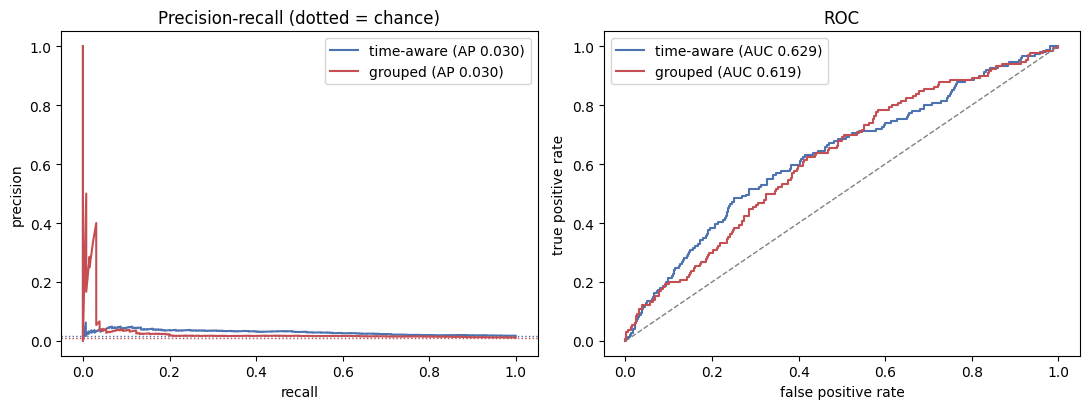

In [3]:
res = {}
for tag, model, test in [('time-aware', ta_model, ta_test), ('grouped', gr_model, gr_test)]:
    p = model.predict_proba(test[FEATS])[:, 1]
    res[tag] = {'p_raw': p, 'y': test.injury.values, 'dates': test.Date.values,
                'ap': float(average_precision_score(test.injury, p)),
                'auc': float(roc_auc_score(test.injury, p)),
                'chance': float(test.injury.mean())}

tbl = pd.DataFrame({t: {'test AP': r['ap'], 'chance AP': r['chance'],
                        'lift': r['ap'] / r['chance'], 'test AUC': r['auc']}
                    for t, r in res.items()}).T
print(tbl.round(4).to_string())
print(f"\npaper day-approach test AUC {SEL['paper_benchmark_auc']['day']} (SD 0.01)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for tag, c in [('time-aware', '#4C72B0'), ('grouped', '#C44E52')]:
    r = res[tag]
    pr, rc, _ = precision_recall_curve(r['y'], r['p_raw'])
    ax1.plot(rc, pr, color=c, label=f"{tag} (AP {r['ap']:.3f})")
    ax1.axhline(r['chance'], color=c, ls=':', lw=1)
    fpr, tpr, _ = roc_curve(r['y'], r['p_raw'])
    ax2.plot(fpr, tpr, color=c, label=f"{tag} (AUC {r['auc']:.3f})")
ax1.set(xlabel='recall', ylabel='precision', title='Precision-recall (dotted = chance)')
ax1.legend()
ax2.plot([0, 1], [0, 1], color='gray', ls='--', lw=1)
ax2.set(xlabel='false positive rate', ylabel='true positive rate', title='ROC')
ax2.legend()
plt.tight_layout()

## 3. Calibration on test

Does "10% risk" mean 10%? Reliability curves on Platt-calibrated scores, 10 quantile
bins. Brier reference = always predicting the dev-side prevalence (the constant a
deployed tool would otherwise use).

            Brier calibrated  Brier raw  Brier base-rate ref
split                                                       
time-aware           0.01727    0.24501              0.01733
grouped              0.01156    0.26230              0.01155


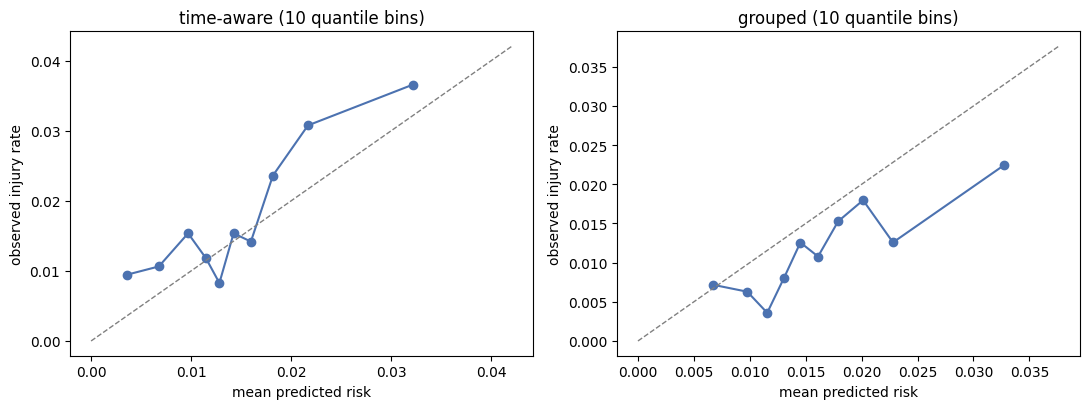

In [4]:
p0 = {'time-aware': float(ta_train.injury.mean()), 'grouped': float(gr_dev.injury.mean())}
cal_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, tag, cal in [(axes[0], 'time-aware', ta_cal), (axes[1], 'grouped', gr_cal)]:
    r = res[tag]
    pc = cal.predict(r['p_raw'])
    r['p_cal'] = pc
    g = pd.DataFrame({'y': r['y'], 'p': pc}).groupby(
        pd.qcut(pc, 10, duplicates='drop'), observed=True)
    ax.plot(g.p.mean(), g.y.mean(), 'o-', color='#4C72B0')
    lim = max(g.p.mean().max(), g.y.mean().max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', lw=1)
    ax.set(title=f'{tag} (10 quantile bins)', xlabel='mean predicted risk',
           ylabel='observed injury rate')
    cal_rows.append({'split': tag,
                     'Brier calibrated': float(brier_score_loss(r['y'], pc)),
                     'Brier raw': float(brier_score_loss(r['y'], r['p_raw'])),
                     'Brier base-rate ref': float(np.mean((r['y'] - p0[tag]) ** 2))})
plt.tight_layout()
cal_tbl = pd.DataFrame(cal_rows).set_index('split')
print(cal_tbl.round(5).to_string())

## 4. Alert budget (thresholds frozen on validation)

The operational question: if staff can act on k flags per week, what do they get?
Threshold for k flags/week is set so *validation* averages k flags/week, then applied
unchanged to test. Achieved flags/week on test drifting from the budget is itself a
finding (score drift), so it is reported.

In [5]:
KS = [1, 2, 3, 5, 10]
def frozen_thresholds(p_cal, dates, ks):
    n_weeks = pd.Series(dates // 7).nunique()
    srt = np.sort(p_cal)[::-1]
    return {k: float(srt[min(len(srt), int(round(k * n_weeks))) - 1]) for k in ks}

thr = {'time-aware': frozen_thresholds(ta_cal.predict(p_val), ta_val.Date.values, KS),
       'grouped':    frozen_thresholds(gr_cal.predict(oof), gr_dev.Date.values, KS)}

alert_rows = []
for tag, r in res.items():
    n_weeks = pd.Series(r['dates'] // 7).nunique()
    for k in KS:
        t = thr[tag][k]
        flag = r['p_cal'] >= t
        tp = int(r['y'][flag].sum())
        alert_rows.append({'split': tag, 'budget/wk': k, 'threshold': round(t, 4),
                           'flags': int(flag.sum()), 'achieved/wk': flag.sum() / n_weeks,
                           'true pos': tp, 'precision': tp / max(1, int(flag.sum())),
                           'recall': tp / int(r['y'].sum())})
alert_tbl = pd.DataFrame(alert_rows).set_index(['split', 'budget/wk'])
print(alert_tbl.round(4).to_string())
print(f"\npaper's implied operating point for contrast: ~3% precision (58.4% sens / 74.1% spec at 1.4% prevalence)")

                      threshold  flags  achieved/wk  true pos  precision  recall
split      budget/wk                                                            
time-aware 1             0.0412     84       0.9655         3     0.0357  0.0201
           2             0.0367    136       1.5632         4     0.0294  0.0268
           3             0.0341    192       2.2069         7     0.0365  0.0470
           5             0.0303    327       3.7586        14     0.0428  0.0940
           10            0.0262    628       7.2184        24     0.0382  0.1611
grouped    1             0.0354    128       0.3478         5     0.0391  0.0385
           2             0.0306    320       0.8696        12     0.0375  0.0923
           3             0.0284    526       1.4293        16     0.0304  0.1231
           5             0.0252   1002       2.7228        24     0.0240  0.1846
           10            0.0213   2239       6.0842        39     0.0174  0.3000

paper's implied operating p

## 5. Subgroups (grouped test)

Median splits with cutoffs computed on dev athletes only; then the per-athlete AUC
spread - the check that catches a model that works on average but fails a third of
the runners. Small-n caveat applies to every cell below; positives per bin are
printed for that reason.

In [6]:
dev_stats  = gr_dev.groupby('Athlete ID').agg(rows=('injury', 'size'), km=('km_sum__w7', 'mean'))
test_stats = gr_test.groupby('Athlete ID').agg(rows=('injury', 'size'), km=('km_sum__w7', 'mean'))
cuts = {'tenure (rows)': ('rows', float(dev_stats.rows.median())),
        'volume (mean 7d km)': ('km', float(dev_stats.km.median()))}

df = gr_test[['Athlete ID']].copy()
df['y'] = res['grouped']['y']
df['p'] = res['grouped']['p_raw']

sub_rows = []
for dim, (col, cut) in cuts.items():
    for side, ids in [('low',  test_stats.index[test_stats[col] <= cut]),
                      ('high', test_stats.index[test_stats[col] > cut])]:
        s = df[df['Athlete ID'].isin(ids)]
        both = s.y.nunique() == 2
        sub_rows.append({'dim': dim, 'group': side, 'athletes': len(ids), 'rows': len(s),
                         'pos': int(s.y.sum()), 'chance AP': float(s.y.mean()),
                         'AP': float(average_precision_score(s.y, s.p)) if both else np.nan,
                         'AUC': float(roc_auc_score(s.y, s.p)) if both else np.nan})
sub_tbl = pd.DataFrame(sub_rows).set_index(['dim', 'group'])
print(sub_tbl.round(4).to_string())
print(f"\ncutoffs (dev-side): tenure {cuts['tenure (rows)'][1]:.0f} rows, "
      f"volume {cuts['volume (mean 7d km)'][1]:.1f} km")

pa = []
for a, s in df.groupby('Athlete ID'):
    if s.y.nunique() == 2:
        pa.append({'athlete': int(a), 'rows': len(s), 'pos': int(s.y.sum()),
                   'AUC': float(roc_auc_score(s.y, s.p))})
pa = pd.DataFrame(pa).set_index('athlete').sort_values('AUC')
n_all = gr_test['Athlete ID'].nunique()
print(f'\nper-athlete AUC ({len(pa)} of {n_all} test athletes have both classes):')
print(pa.round(3).to_string())
print(f'\nmedian {pa.AUC.median():.3f} | IQR {pa.AUC.quantile(.25):.3f}-{pa.AUC.quantile(.75):.3f}'
      f' | athletes below 0.5: {int((pa.AUC < .5).sum())}')

                           athletes  rows  pos  chance AP      AP     AUC
dim                 group                                                
tenure (rows)       low          10  2559   37     0.0145  0.0975  0.6649
                    high          8  8574   93     0.0108  0.0178  0.6244
volume (mean 7d km) low           4  2190   41     0.0187  0.0495  0.6735
                    high         14  8943   89     0.0100  0.0272  0.6016

cutoffs (dev-side): tenure 484 rows, volume 37.7 km

per-athlete AUC (15 of 18 test athletes have both classes):
         rows  pos    AUC
athlete                  
4         681    7  0.273
55         48    1  0.298
22       1478   21  0.500
48        381    4  0.542
63        516    2  0.566
54       1207    8  0.642
23       1393   24  0.644
43       1471   15  0.677
24        756    3  0.711
7         304    5  0.715
68        235    8  0.722
10        387   10  0.760
47       1072   13  0.810
21        290    6  0.820
14        272    3  0.829


## 6. Lead-time sensitivity (`__w6`, discrimination only)

Same winner config on the 6-slot window: how much signal survives if the tool must
flag two days ahead instead of one? Not a full battery - one question, two numbers.

In [7]:
ta6 = logit_pipe().fit(ta_train[W6_FEATS], ta_train.injury)
gr6 = logit_pipe().fit(gr_dev[W6_FEATS], gr_dev.injury)
w6_rows = []
for tag, m6, test in [('time-aware', ta6, ta_test), ('grouped', gr6, gr_test)]:
    p6 = m6.predict_proba(test[W6_FEATS])[:, 1]
    w6_rows.append({'split': tag,
                    'w7 AP': res[tag]['ap'],
                    'w6 AP': float(average_precision_score(test.injury, p6)),
                    'w7 AUC': res[tag]['auc'],
                    'w6 AUC': float(roc_auc_score(test.injury, p6))})
w6_tbl = pd.DataFrame(w6_rows).set_index('split')
print('w7 = flag the day before; w6 = two days before')
print(w6_tbl.round(4).to_string())

w7 = flag the day before; w6 = two days before
             w7 AP   w6 AP  w7 AUC  w6 AUC
split                                     
time-aware  0.0301  0.0291  0.6288  0.6246
grouped     0.0301  0.0318  0.6193  0.6125


In [8]:
out = {
    'winner': 'logistic C=0.01, w7 raw+z, class weights',
    'design': {'ta_model': 'fit on train only; val spent once on Platt calibrator',
               'gr_model': 'fit on all dev athletes; Platt on cross-fitted OOF preds',
               'thresholds': 'frozen on validation at 1/2/3/5/10 flags per week'},
    'headline': {t: {'ap': r['ap'], 'auc': r['auc'], 'chance_ap': r['chance'],
                     'n_rows': int(len(r['y'])), 'n_pos': int(r['y'].sum())}
                 for t, r in res.items()},
    'calibration': {c['split']: {k: v for k, v in c.items() if k != 'split'} for c in cal_rows},
    'alert_budget': alert_rows,
    'subgroups': sub_tbl.reset_index().to_dict(orient='records'),
    'per_athlete_auc': pa.reset_index().to_dict(orient='records'),
    'w6_sensitivity': w6_tbl.reset_index().to_dict(orient='records'),
    'thresholds_frozen_on_validation': thr,
    'paper_benchmark_auc': SEL['paper_benchmark_auc'],
}
json.dump(out, open(PROC / 'evaluation_results.json', 'w'), indent=2, default=float)
print('wrote', PROC / 'evaluation_results.json')

wrote ../data/processed/evaluation_results.json


## Summary (written after the one-shot run; numbers final)

- **Headline: test AP 0.030 on both splits** - 1.7x chance (time-aware, prevalence
  0.0176) and 2.6x chance (grouped, prevalence 0.0117). AUC 0.629 / 0.619 vs the
  paper's 0.724 and our own grouped CV estimate of 0.690.
- **The grouped CV -> test drop (0.690 -> 0.619) is the per-athlete spread doing
  exactly what check (c) predicted.** 18 test athletes, per-athlete AUC ranging
  0.27-0.83, 2 of 15 below 0.5 (athlete 4: AUC 0.27 across 7 injuries). With CV AP
  sd 0.021, a test draw this size moves the number a lot; the average hides athletes
  the model actively misranks.
- **Calibration: Platt repairs the gross miscalibration (Brier 0.245 -> 0.0173 TA,
  0.262 -> 0.0116 GR) but lands statistically tied with always predicting the base
  rate** (refs 0.0173 / 0.0116). Honest reading: the score is a useful *ranking*
  with weak *sharpness* - absolute risk numbers should be shown as bands, not
  percentages, in any decision-support layer.
- **Alert budget: 2.9-4.3% precision at 1-5 flags/week, recall 2-18%.** In the same
  ballpark as the paper's implied ~3% precision, made explicit instead of implied.
  On the grouped test the frozen thresholds under-flag the budget (0.35/wk at the
  1/wk setting) - the held-out athletes score lower overall (they are a
  lower-prevalence pool), which is itself a deployment lesson: budgets set on one
  population drift on another.
- **Subgroups: the model is better for shorter-tenure and lower-volume athletes**
  (AUC 0.66-0.67 vs 0.60-0.62 for the high halves; low-tenure AP 0.098 = 6.7x its
  chance). Positives per bin are 37-93, so treat as direction, not precision.
- **Lead time is nearly free: w6 matches w7** (grouped AP 0.032 vs 0.030, AUC
  -0.007). Flagging two days ahead instead of one costs almost nothing - the more
  operationally useful window at no measurable price.

Next: the decision-support layer reads `evaluation_results.json` and must carry the
calibration caveat and the per-athlete-spread caveat on its face.